# Fase 3 - Clustering de canciones (K=4)

Agrupamos canciones por su "vibe" de audio, sin usar el género. La lógica vive en `src/`
(`features.scale`, `cluster.*`); aquí la usamos, visualizamos y la interpretamos.

Decisión clave: el silhouette es máximo en K=2, pero K=2 solo separa "enérgicas vs acústicas",
demasiado grueso para el objetivo del proyecto (vibes ricas). Elegimos **K=4** asumiendo un
silhouette algo menor a cambio de grupos mucho más interpretables. La métrica no es el objetivo.

In [1]:
# Bootstrap: permite ejecutar desde cualquier carpeta (p.ej. jupyter nbconvert).
import sys
from pathlib import Path
_root = Path.cwd()
while not (_root / "config.yaml").exists() and _root != _root.parent:
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.decomposition import PCA
import umap

from src.config import load_config, path
from src import data, features, cluster

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 130, "axes.titleweight": "bold"})
cfg = load_config(); REPORTS = path(cfg["paths"]["reports"]); SEED = cfg["seed"]
AUDIO = cfg["features"]["audio"]

songs, n_dups = data.clean(data.load_raw(cfg))
X, scaler = features.scale(songs, cfg)
print(f"Canciones: {len(songs):,} | features de audio: {len(AUDIO)}")

C:\Users\omar1\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Canciones: 89,740 | features de audio: 9


## Cuántos clusters: codo + silhouette

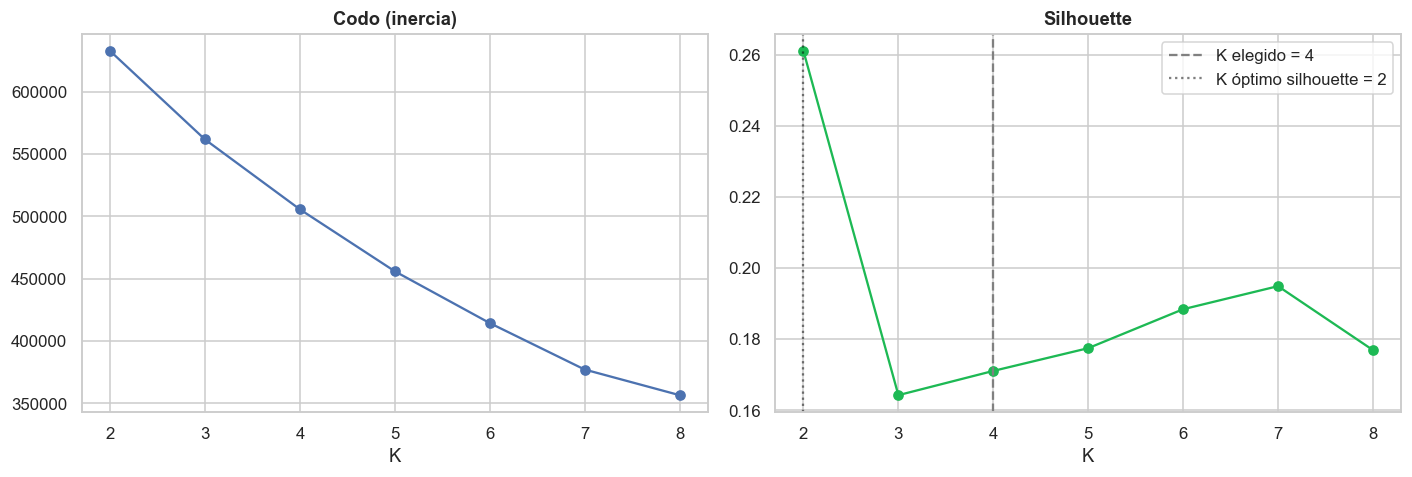

{2: 0.261, 3: 0.164, 4: 0.171, 5: 0.177, 6: 0.188, 7: 0.195, 8: 0.177}


In [2]:
curva = cluster.silhouette_curve(X, cfg["clustering"]["k_range"], cfg["clustering"]["silhouette_sample"], SEED)
ks = list(curva)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(ks, [curva[k]["inertia"] for k in ks], "o-"); ax[0].set_title("Codo (inercia)"); ax[0].set_xlabel("K")
ax[1].plot(ks, [curva[k]["silhouette"] for k in ks], "o-", color="#1DB954")
ax[1].axvline(4, ls="--", color="gray", label="K elegido = 4")
ax[1].axvline(2, ls=":", color="black", alpha=.5, label="K óptimo silhouette = 2")
ax[1].set_title("Silhouette"); ax[1].set_xlabel("K"); ax[1].legend()
fig.tight_layout(); fig.savefig(REPORTS/"08_elbow_silhouette.png", bbox_inches="tight"); plt.show()
print({k: round(curva[k]["silhouette"], 3) for k in ks})

## K-Means con K=4 y nombres interpretables

In [3]:
K = cfg["clustering"]["k"]
km, labels = cluster.fit(X, K, SEED)
songs = songs.assign(cluster=labels)
nombres = cluster.name_clusters(songs, labels, AUDIO)
for c in sorted(nombres):
    print(f"Cluster {c} ({int((labels==c).sum()):,}): {nombres[c]}")

Cluster 0 (18,648): Altas en acústicas, bajas en enérgicas
Cluster 1 (7,001): Altas en en vivo, bajas en instrumentales
Cluster 2 (36,646): Altas en alegres, bajas en instrumentales
Cluster 3 (27,445): Altas en enérgicas, bajas en acústicas


## Visualización: PCA y UMAP

C:\Users\omar1\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


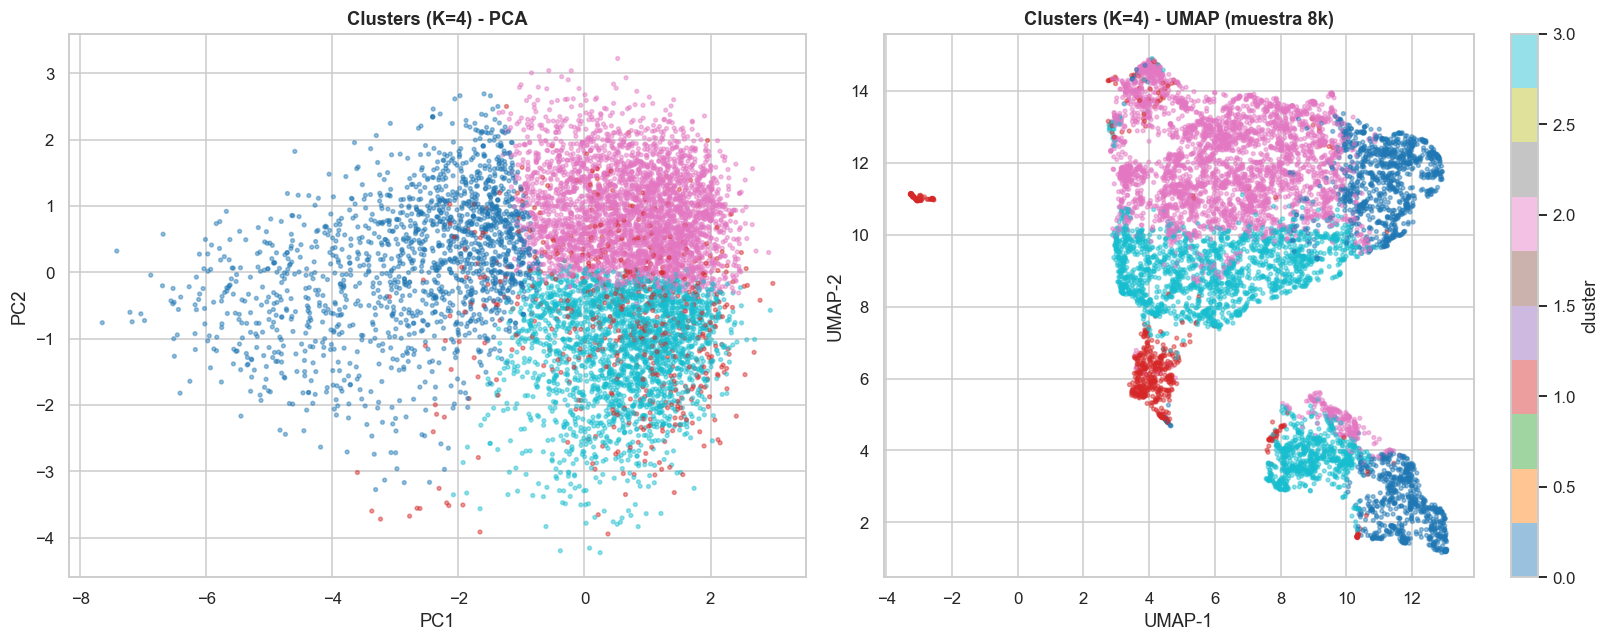

In [4]:
rng = np.random.RandomState(SEED)
samp = rng.choice(len(X), 8000, replace=False)
Xp = PCA(n_components=2, random_state=SEED).fit_transform(X)
Xu = umap.UMAP(n_components=2, random_state=SEED).fit_transform(X[samp])

fig, ax = plt.subplots(1, 2, figsize=(15, 6))
sc0 = ax[0].scatter(Xp[samp,0], Xp[samp,1], c=labels[samp], cmap="tab10", s=6, alpha=.45)
ax[0].set_title(f"Clusters (K={K}) - PCA"); ax[0].set_xlabel("PC1"); ax[0].set_ylabel("PC2")
sc1 = ax[1].scatter(Xu[:,0], Xu[:,1], c=labels[samp], cmap="tab10", s=6, alpha=.45)
ax[1].set_title(f"Clusters (K={K}) - UMAP (muestra 8k)"); ax[1].set_xlabel("UMAP-1"); ax[1].set_ylabel("UMAP-2")
plt.colorbar(sc1, ax=ax[1], label="cluster")
fig.tight_layout()
fig.savefig(REPORTS/"09_clusters_pca.png", bbox_inches="tight")

## Perfil de cada cluster (z-score vs media global)

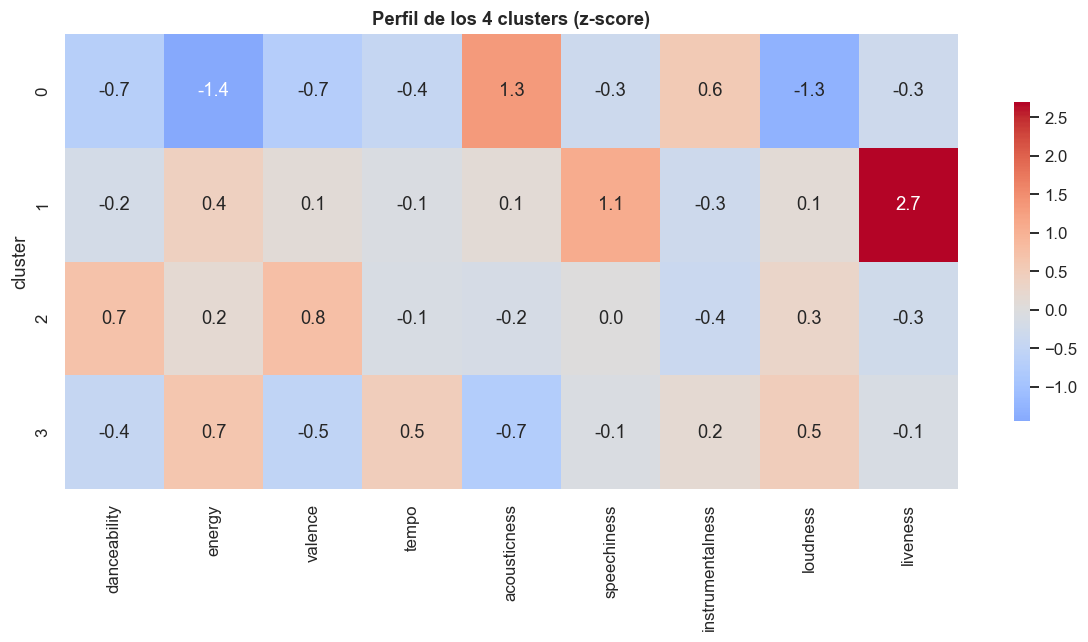

In [5]:
prof = songs.groupby("cluster")[AUDIO].mean()
z = (prof - songs[AUDIO].mean()) / songs[AUDIO].std()
fig, ax = plt.subplots(figsize=(11, 1.0*K + 2))
sns.heatmap(z, cmap="coolwarm", center=0, annot=True, fmt=".1f", ax=ax, cbar_kws={"shrink":.7})
ax.set_title(f"Perfil de los {K} clusters (z-score)"); ax.set_ylabel("cluster")
fig.tight_layout(); fig.savefig(REPORTS/"10_cluster_profiles.png", bbox_inches="tight"); plt.show()

## Canciones representativas y cruce con género

In [6]:
for c in sorted(songs.cluster.unique()):
    top = songs[songs.cluster==c].nlargest(3, "popularity")[["track_name","artists","popularity"]]
    print(f"\nCluster {c} - {nombres[c]}")
    print(top.to_string(index=False))

print("\nGénero dominante por cluster:")
ct = pd.crosstab(songs.cluster, songs.track_genre)
for c in ct.index:
    print(f"  Cluster {c}: {ct.loc[c].idxmax()} ({100*ct.loc[c].max()/ct.loc[c].sum():.0f}% del cluster)")


Cluster 0 - Altas en acústicas, bajas en enérgicas
                            track_name   artists  popularity
                         Glimpse of Us      Joji          94
                          Another Love Tom Odell          93
Running Up That Hill (A Deal With God) Kate Bush          90

Cluster 1 - Altas en en vivo, bajas en instrumentales
   track_name                 artists  popularity
Ojitos Lindos Bad Bunny;Bomba Estéreo          95
        Tarot        Bad Bunny;Jhayco          91
    You Proof           Morgan Wallen          86

Cluster 2 - Altas en alegres, bajas en instrumentales
                           track_name                    artists  popularity
Quevedo: Bzrp Music Sessions, Vol. 52           Bizarrap;Quevedo          99
                           La Bachata              Manuel Turizo          98
                      Me Porto Bonito Bad Bunny;Chencho Corleone          97

Cluster 3 - Altas en enérgicas, bajas en acústicas
               track_name         

## Conclusiones

- Con **K=4** los grupos se vuelven interpretables: acústicas/tranquilas, en vivo, alegres y
  enérgicas. El silhouette baja respecto a K=2 (0.26 -> ~0.17): es el precio de tener "vibes"
  más finas en vez de un corte grueso. La métrica óptima no siempre da el resultado más útil.
- **UMAP** separa los grupos mejor que PCA visualmente.
- Los clusters **cruzan géneros** (el género dominante de cada uno es minoritario): capturan la
  sonoridad, no la etiqueta. Sirve para recomendar por similitud (siguiente fase).